# Demo using builders

In [1]:
import os
import random
import numpy as np
from eclypse.builders.infrastructure.generators import random as random_builder
from network import Network

# Fix the seed for the experiments
EXPERIMENT_SEED = 42
random.seed(EXPERIMENT_SEED)
np.random.seed(EXPERIMENT_SEED)

# Generate the infrastructure by passing the Network class as argument
infra = random_builder.get_random(
    n=20,
    p=0.3,
    seed=EXPERIMENT_SEED,
    infrastructure_cls=Network
)

print(f"Network infrastructure: {infra.number_of_nodes()} nodes, {infra.number_of_edges()} edges.")

Network infrastructure: 20 nodes, 67 edges.


/tmp/ipykernel_27282/650137200.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


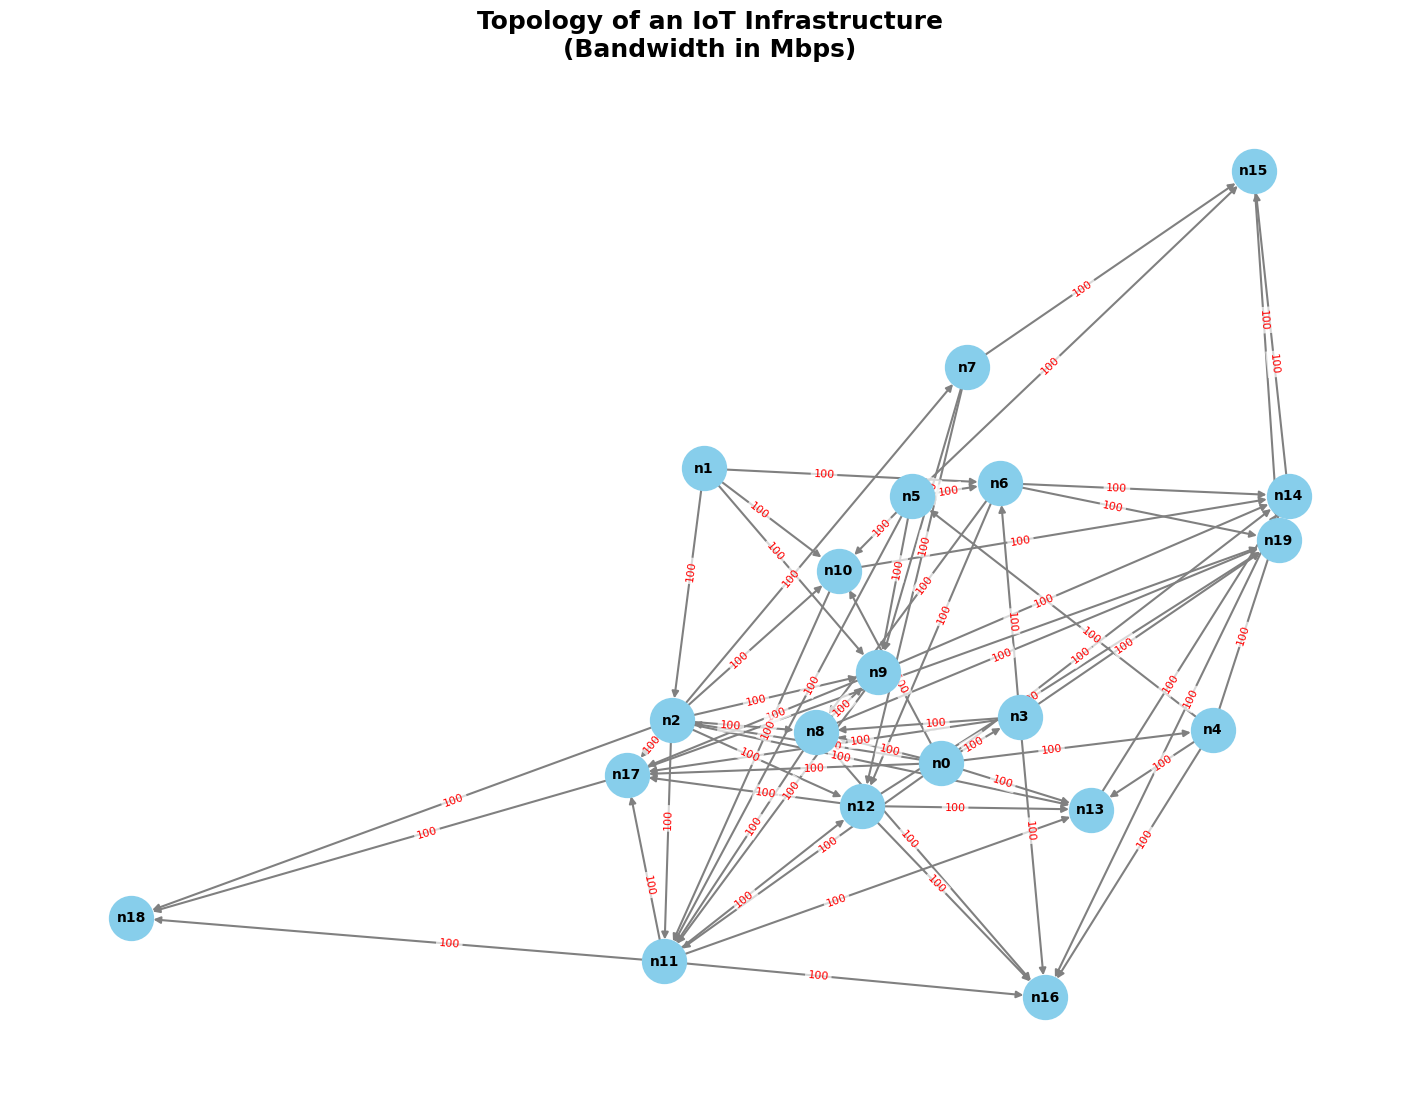

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

pos_base = nx.kamada_kawai_layout(infra)
pos = nx.spring_layout(infra, pos=pos_base, k=2.5, iterations=100, seed=42)

nx.draw(
    infra,
    pos,
    with_labels=True,
    node_color='skyblue',
    node_size=1000,
    font_size=10,
    font_weight='bold',
    edge_color='gray',
    width=1.5
)

edge_labels = nx.get_edge_attributes(infra, 'bandwidth_mbps')
if edge_labels:
    formatted_labels = {
        edge: f"{int(bw)}" if bw % 1 == 0 else f"{bw}"
        for edge, bw in edge_labels.items()
    }

    nx.draw_networkx_edge_labels(
        infra,
        pos,
        edge_labels=formatted_labels,
        font_color='red',
        font_size=8,
        label_pos=0.4,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2)
    )

plt.title("Topology of an IoT Infrastructure\n(Bandwidth in Mbps)", fontsize=18, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
plt.show()

In [3]:
from network_application import NetworkAwareApplication
from packet_generation import PacketGenerationEvent
from traffic_event import TrafficRoutingExecutionEvent
from traffic_metric import TrafficRoutingMetric
from eclypse.simulation import SimulationConfig
from eclypse.simulation import Simulation
from eclypse.placement.strategies import StaticStrategy
app = NetworkAwareApplication("VideoApp")

app.add_node("Sensor1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("Sensor2", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)
app.add_node("Cloud1", cpu=0, ram=0, gpu=0, storage=0, availability=0.0)

app.add_edge("Sensor1",
             "Cloud1",
             packet_size_bytes=1500,
             avg_packets_per_step=10,
             bandwidth=0,
             latency=1000
            )

app.add_edge("Sensor2",
             "Cloud1",
             packet_size_bytes=1500,
             avg_packets_per_step=10,
             bandwidth=0,
             latency=1000
            )
packet_event = PacketGenerationEvent()

execution_event = TrafficRoutingExecutionEvent(step_duration_s=0.0005)
reporting_metric = TrafficRoutingMetric()

sim_config = SimulationConfig(
    seed=42,
    max_steps=11,
    step_every_ms=500,
    path="./results",
    events=[packet_event, execution_event, reporting_metric],
    include_default_metrics=False,
    report_format="json",
    report_backend="pandas",
    remote=False
)

print("3. Initializing Simulation...")
sim = Simulation(infra, simulation_config=sim_config)

strategy = StaticStrategy({
    "Sensor1": "n7",
    "Sensor2": "n5",
    "Cloud1": "n18"
})
sim.register(app, placement_strategy=strategy)

sim.start()
sim.wait()

17:39:12.376 | INFO | VideoApp - Added flow Sensor1->Cloud1, 10 pkt/step (avg), pkt/step (avg), size 1500B
17:39:12.377 | INFO | VideoApp - Added flow Sensor2->Cloud1, 10 pkt/step (avg), pkt/step (avg), size 1500B
3. Initializing Simulation...
17:39:12.622 | ECLYPSE | Simulation - Simulation configuration | infrastructure=random | path=results | remote=False | step_every_ms=500 | max_steps=11 | seed=42 | report_format=json | report_backend=pandas | log_level=ECLYPSE | log_to_file=False | include_default_metrics=False
17:39:12.629 | INFO | random - n7 order: [1 (APP), 2 (APP), 3 (APP), 4 (APP), 5 (APP), 6 (APP), 7 (APP), 8 (APP), 9 (APP), 10 (APP), 11 (APP), 12 (APP)]
17:39:12.623 | ECLYPSE | Simulation - Simulation started.
17:39:12.631 | INFO | random - n5 order: [13 (APP), 14 (APP), 15 (APP), 16 (APP), 17 (APP), 18 (APP)]
17:39:12.628 | ECLYPSE | PlacementManager - Placement established | app=VideoApp | mapping={'Sensor1': 'n7', 'Sensor2': 'n5', 'Cloud1': 'n18'}
17:39:12.628 | ECLYPS

In [4]:
import pandas as pd
import json
import os
# Load the JSONL file and extract metrics
json_path = "./results/json/application.jsonl"
records = []

if not os.path.exists(json_path):
    raise FileNotFoundError(f"File {json_path} not found")

with open(json_path, 'r') as file:
    for line in file:
        if line.strip():
            metrics = [m for m in json.loads(line).get("data", []) if len(m) == 3]
            for app_id, metric_name, val in metrics:
                records.append({'metric': str(metric_name), 'val': val})

if not records:
    raise ValueError("The JSONL file is empty or does not contain valid metrics.")

df_raw = pd.DataFrame(records)

# Extract Step, Packet_ID, Hop_ID and Field from the metric naming convention
extracted = df_raw['metric'].str.extract(r'step_(\d+)_pkt_(\d+)_hop_(\d+)_(.*)')

df_raw['Step'] = extracted[0].astype(float)
df_raw['Packet_ID'] = extracted[1].astype(float)
df_raw['Hop_ID'] = extracted[2].astype(float)
df_raw['Field'] = extracted[3]

# Filter the DataFrame to keep only rows that have valid Packet_IDs (i.e., those that match the expected pattern)
df_hops = df_raw.dropna(subset=['Packet_ID']).copy()

# Convert the relevant columns to integers
df_hops['Step'] = df_hops['Step'].astype(int)
df_hops['Packet_ID'] = df_hops['Packet_ID'].astype(int)
df_hops['Hop_ID'] = df_hops['Hop_ID'].astype(int)

# Group by Step, Packet_ID, and Hop_ID
df_pivot = df_hops.pivot_table(
    index=['Step', 'Packet_ID', 'Hop_ID'],
    columns='Field',
    values='val',
    aggfunc='first'
).reset_index()

# Conversion into numeric types for the relevant columns
numeric_cols = ['arrival_at_next', 'processing_ms', 'queue_ms', 'transmission_ms', 'propagation_ms']
for col in numeric_cols:
    if col in df_pivot.columns:
        df_pivot[col] = pd.to_numeric(df_pivot[col], errors='coerce')

df_pivot['queue_length'] = pd.to_numeric(df_pivot.get('queue_length', 0)).fillna(0).astype(int)

# Security check: if the 'hop' string is not in the JSON due to ECLYPSE limitations, add a default value
if 'hop' not in df_pivot.columns:
    df_pivot['hop'] = "Route N/A"

# Print the chronological log of hops
print("\n--- Chronological Log of Hops ---")

# Order by the absolute arrival timestamp
df_log = df_pivot.sort_values('arrival_at_next').dropna(subset=['arrival_at_next'])

for _, row in df_log.iterrows():
    # Extract the route name from the 'hop' field, which is expected to be a string like "Sensor->Gateway"
    route_name = str(row['hop'])

    print(f"[Arrival: {row['arrival_at_next']:7.4f} ms] | "
          f"Step: {row['Step']:<3} | "
          f"Pkt: {row['Packet_ID']:<3} (Hop {row['Hop_ID']}) | "
          f"Route: {route_name:<15} | "
          f"Queue: {row['queue_length']:>2} pkt | "
          f"Delay Queue: {row['queue_ms']:6.4f} ms")


--- Chronological Log of Hops ---
[Arrival:  0.6250 ms] | Step: 1   | Pkt: 1   (Hop 1) | Route: n7->n9          | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.6250 ms] | Step: 1   | Pkt: 13  (Hop 1) | Route: n5->n11         | Queue:  1 pkt | Delay Queue: 0.0000 ms
[Arrival:  0.7450 ms] | Step: 1   | Pkt: 14  (Hop 1) | Route: n5->n11         | Queue:  2 pkt | Delay Queue: 0.1200 ms
[Arrival:  0.7450 ms] | Step: 1   | Pkt: 2   (Hop 1) | Route: n7->n9          | Queue:  2 pkt | Delay Queue: 0.1200 ms
[Arrival:  0.8650 ms] | Step: 1   | Pkt: 3   (Hop 1) | Route: n7->n9          | Queue:  3 pkt | Delay Queue: 0.2400 ms
[Arrival:  0.8650 ms] | Step: 1   | Pkt: 15  (Hop 1) | Route: n5->n11         | Queue:  3 pkt | Delay Queue: 0.2400 ms
[Arrival:  0.9850 ms] | Step: 1   | Pkt: 16  (Hop 1) | Route: n5->n11         | Queue:  4 pkt | Delay Queue: 0.3600 ms
[Arrival:  0.9850 ms] | Step: 1   | Pkt: 4   (Hop 1) | Route: n7->n9          | Queue:  4 pkt | Delay Queue: 0.3600 ms
[Arrival:  1.